# Cold augmentations
Blender renders get augmented in various ways and then saved to disk as a dataset

In [2]:
from PIL import Image
import random
import math
import os
import numpy as np
import cv2

from datasets import multi_coin_ds


def apply_directional_blur_to_image(img, angle_degrees=0.0, kernel_size=15):
    """Apply directional blur to a PIL Image"""

    def make_motion_blur_kernel(size, angle):
        kernel = np.zeros((size, size), dtype=np.float32)
        kernel[size // 2, :] = np.ones(size, dtype=np.float32)
        kernel /= kernel.sum()
        center = (size // 2, size // 2)
        rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(kernel, rot_mat, (size, size))
        rotated /= rotated.sum()
        return rotated

    # Convert PIL Image to numpy array
    img_np = np.array(img)

    # Apply blur to each channel independently
    k = make_motion_blur_kernel(kernel_size, angle_degrees)
    if img_np.ndim == 3:
        blurred = np.stack([cv2.filter2D(img_np[..., c], -1, k) for c in range(img_np.shape[-1])], axis=-1)
    else:
        blurred = cv2.filter2D(img_np, -1, k)

    # Convert back to PIL Image
    return Image.fromarray(blurred.astype(np.uint8))


def make_ds(
        dir,
        output_dir,

        background_dir=None,
        background_colour=(127, 127, 127),

        zoom=(0.9, 1.1),
        horizontal=0.1,
        vertical=0.1,
        rotation=(-5, 5),

        blur_angle_range=(-45, 45),
        blur_kernel_range=(5, 25),

        zoom_prob=0,
        horizontal_prob=0,
        vertical_prob=0,
        rotation_prob=0,
        blur_prob=0,

        seed=42
):
    assert background_dir is not None or background_colour is not None, "define background"

    import os
    import shutil
    import numpy as np

    random.seed(seed)
    rng = np.random.default_rng(seed)

    def augment_background(foreground_path, output_path, target_background):
        foreground = Image.open(foreground_path).convert("RGBA")
        width, height = foreground.size

        if isinstance(target_background, str):
            background = Image.open(target_background).convert("RGBA")
        elif isinstance(target_background, Image.Image):
            background = target_background.convert("RGBA")
        elif isinstance(target_background, tuple):
            # solid color canvas same size as foreground (no implicit zoom)
            background = Image.new("RGBA", (width, height), target_background)
        else:
            raise TypeError("target_background")

        # Original background size (no pre-scaling here)
        bg_w, bg_h = background.size

        # --- Apply zoom ONLY when zoom_prob triggers ---
        if rng.random() < zoom_prob:
            z = float(rng.uniform(zoom[0], zoom[1]))
            new_w = max(1, int(round(bg_w * z)))
            new_h = max(1, int(round(bg_h * z)))
            # Resize background to exactly bg * z
            background = background.resize((new_w, new_h), Image.LANCZOS)
            bg_w, bg_h = background.size

        # --- Apply rotation ONLY when rotation_prob triggers ---
        if rng.random() < rotation_prob:
            # rotate after any resize. expand=True may increase bg size.
            background = background.rotate(float(rng.uniform(rotation[0], rotation[1])), expand=True)
            bg_w, bg_h = background.size

        # --- Optional directional blur: apply to BOTH background and foreground ---
        if rng.random() < blur_prob:
            blur_angle = float(rng.uniform(blur_angle_range[0], blur_angle_range[1]))
            # sample inclusive-int like rng.integers(low, high+1)
            blur_kernel = int(rng.integers(blur_kernel_range[0], blur_kernel_range[1] + 1))
            # ensure kernel is odd and >= 3
            if blur_kernel % 2 == 0:
                blur_kernel += 1
            blur_kernel = max(3, blur_kernel)

            # Blur background
            background = apply_directional_blur_to_image(background, angle_degrees=blur_angle, kernel_size=blur_kernel)
            # Blur foreground (we blur the whole RGBA image; alpha channel will be preserved)
            foreground = apply_directional_blur_to_image(foreground, angle_degrees=blur_angle, kernel_size=blur_kernel)

            # update sizes in case blur altered dimensions (it shouldn't but just in case)
            bg_w, bg_h = background.size

        # Compose onto a canvas the size of the foreground
        augmented_bg = Image.new("RGBA", (width, height))

        # Center background on canvas, then optionally jitter
        paste_x = (width - bg_w) // 2
        paste_y = (height - bg_h) // 2

        if rng.random() < horizontal_prob:
            paste_x += int(rng.integers(-int(bg_w * horizontal), int(bg_w * horizontal) + 1))
        if rng.random() < vertical_prob:
            paste_y += int(rng.integers(-int(bg_h * vertical), int(bg_h * vertical) + 1))

        augmented_bg.paste(background, (paste_x, paste_y))

        final_image = Image.alpha_composite(augmented_bg, foreground)
        final_image.save(output_path)

    background_images = os.listdir(background_dir) if background_dir is not None else []
    orig_images_dir = os.path.join(dir, 'images')
    dest_images_dir = os.path.join(output_dir, 'images')

    os.makedirs(dest_images_dir, exist_ok=True)

    for fn in filter(lambda x: x.lower().endswith(".png"), os.listdir(orig_images_dir)):
        bg = os.path.join(background_dir,
                          rng.choice(background_images)) if background_dir is not None else background_colour

        augment_background(
            os.path.join(orig_images_dir, fn),
            os.path.join(dest_images_dir, fn),
            bg
        )

    shutil.copy(os.path.join(dir, "annotations.xml"), output_dir)

In [3]:
make_ds(
    "datasets/synthetic-2",
    "datasets/synthetic_bg-2",
    "datasets/backgrounds",
    blur_prob=0.5,
    blur_kernel_range=(5, 15),
    horizontal_prob=0.5,
    vertical_prob=0.25,
    rotation_prob=0.75,
    zoom_prob=0.25,
    seed=42
)

2025-08-11 11:42:20.326201: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-11 11:42:20.763417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754908940.884181     650 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754908940.919061     650 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754908941.269040     650 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

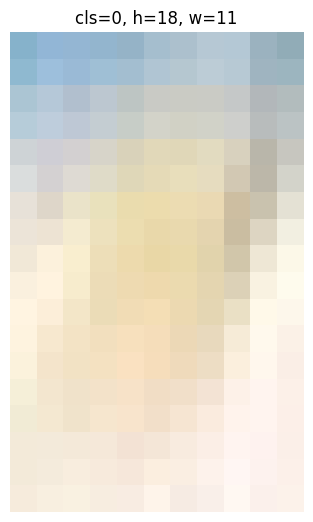

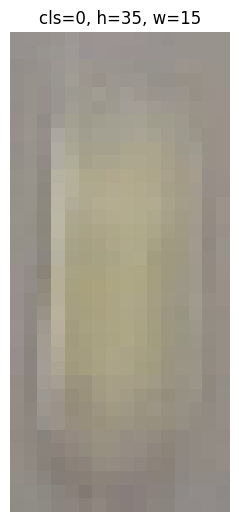

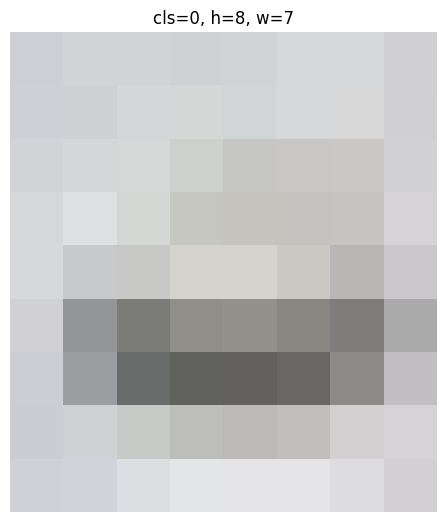

2025-08-11 11:42:48.205804: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [1]:
import datasets
import debugging

ds = datasets.multi_coin_ds([
            ('./datasets/190/annotations.xml', 'PNG'),
            ('./datasets/090/annotations.xml', 'PNG'),
            ('./datasets/90/annotations.xml', 'PNG'),
            ('./datasets/60/annotations.xml', 'PNG'),
            ('./datasets/30/annotations.xml', 'PNG'),
    ], visibility=['distinguishable'],custombg=(255,0,255),format='xywh', d_img=False, d_bb=False, tsz=(1024, 1024))

debugging.visualise_sample_bboxes(
    ds.take(3),hidegraphics=True
)